In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, gca
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))
from Library.dslabs_functions import plot_bar_chart

In [ ]:
df_records = pd.read_excel("../DataBase/DataCollection.xlsx",sheet_name="791 Records")
df_records.shape

(895, 40)

In [10]:
# Média geral de Time (min)
media_geral = df_records["Time (min)"].mean()

# Média de Time (min) quando Dissolution é "Yes"
media_yes = df_records.loc[df_records["Dissolution"] == "YES", "Time (min)"].mean()

# Mediana geral
mediana_geral = df_records["Time (min)"].median()

# Mediana quando Dissolution é "Yes"
mediana_yes = df_records.loc[df_records["Dissolution"] == "YES", "Time (min)"].median()

print(f"Média geral: {media_geral:.2f} min")
print(f"Média (Dissolution=Yes): {media_yes:.2f} min")
print(f"Mediana geral: {mediana_geral:.2f} min")
print(f"Mediana (Dissolution=Yes): {mediana_yes:.2f} min")

Média geral: 75.42 min
Média (Dissolution=Yes): 47.62 min
Mediana geral: 30.00 min
Mediana (Dissolution=Yes): 30.00 min


`Distribution: Plot polymer distribution`

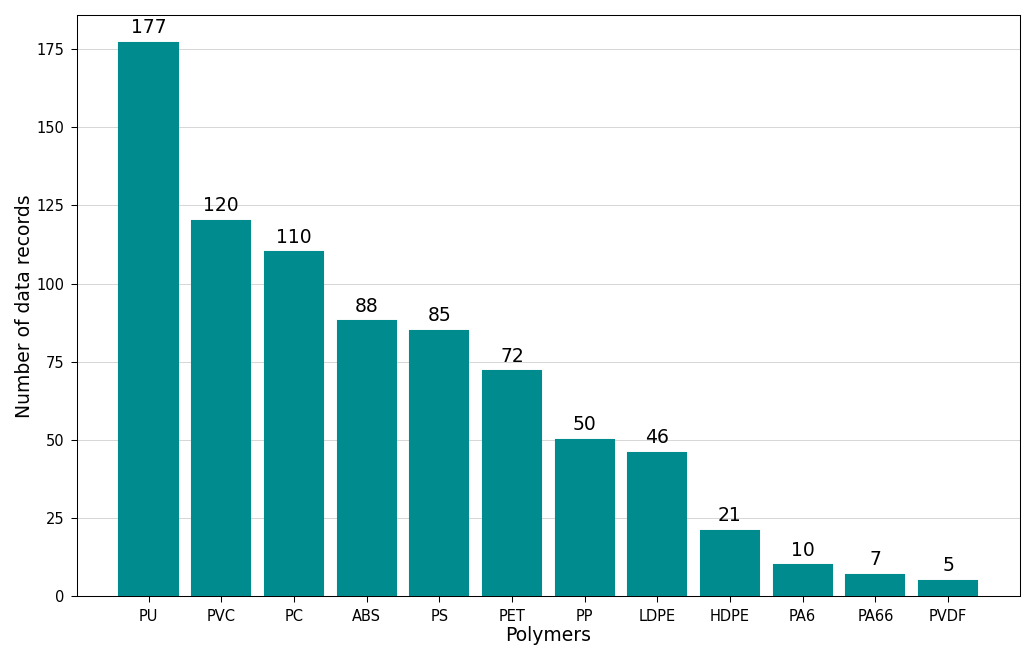

In [ ]:
polymer_counts = df_records["Polymer"].value_counts()

polymer_counts_sorted = polymer_counts.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    polymer_counts_sorted.index,
    polymer_counts_sorted.values,
    color='#008c8e',
    edgecolor='#008c8e',
    zorder=3
)

ax.set_xlabel("Polymers", fontsize=9)
ax.set_ylabel("Number of data records", fontsize=9)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_visible(True)

ax.tick_params(width=0.5, labelsize=7, direction="out")

ax.grid(axis='y', color='gray', linestyle='-', linewidth=0.3, alpha=0.5, zorder=0)

ymax = polymer_counts_sorted.max()
offset = 0.01 * ymax
for bar in bars:
    h = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        h + offset,
        str(int(h)),
        ha='center', va='bottom',
        fontsize=9,
        color="black"
    )

plt.tight_layout()
plt.show()

`Distribution: Plot polymer distribution comparison Original vs Revised`

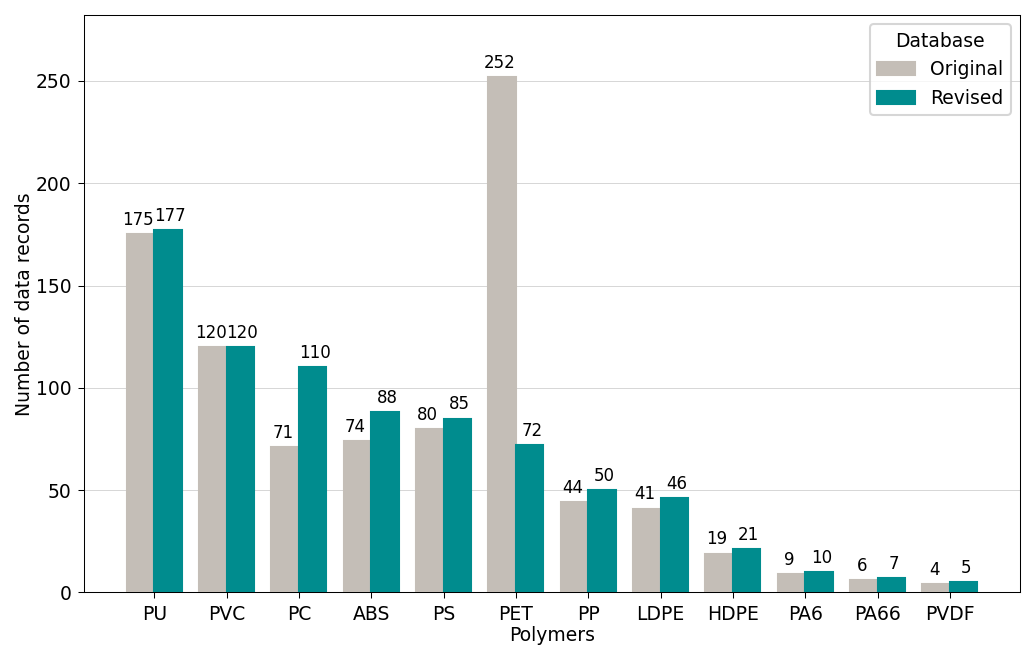

In [6]:
df_original = pd.read_excel("../DataBase/DataCollection.xlsx",sheet_name="895 Records")
df_revised = pd.read_excel("../DataBase/DataCollection.xlsx",sheet_name="791 Records")

counts_original = df_original["Polymer"].value_counts()
counts_revised = df_revised["Polymer"].value_counts()

polymer_order = ["PU", "PVC", "PC", "ABS", "PS", "PET", "PP", "LDPE", "HDPE", "PA6", "PA66", "PVDF"]

polymer_counts = pd.concat(
    [counts_original, counts_revised],
    axis=1,
    keys=["Original", "Revised"]
).fillna(0).astype(int)

polymer_counts = polymer_counts.reindex(polymer_order, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 4.5))

x = np.arange(len(polymer_counts.index))
width = 0.38

bars_original = ax.bar(
    x - width / 2,
    polymer_counts["Original"],
    width,
    label="Original",
    color="#c4beb7",
    edgecolor="#c4beb7",
    zorder=3
)

bars_revised = ax.bar(
    x + width / 2,
    polymer_counts["Revised"],
    width,
    label="Revised",
    color="#008c8e",
    edgecolor="#008c8e",
    zorder=3
)

ax.set_xlabel("Polymers", fontsize=9)
ax.set_ylabel("Number of data records", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(polymer_counts.index)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_visible(True)

ax.tick_params(width=0.5, labelsize=9, direction="out")
ax.grid(axis="y", color="gray", linestyle="-", linewidth=0.3, alpha=0.5, zorder=0)

ymax = polymer_counts.values.max()
offset = 0.01 * ymax

for bar in bars_original:
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2 - 0.03,
            h + offset,
            str(int(h)),
            ha="center",
            va="bottom",
            fontsize=8,
            color="black"
        )

for bar in bars_revised:
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2 + 0.03,
            h + offset,
            str(int(h)),
            ha="center",
            va="bottom",
            fontsize=8,
            color="black"
        )

ax.set_ylim(0, ymax * 1.12)

ax.legend(
    title="Database",
    fontsize=9,
    title_fontsize=9,
    frameon=True
)

plt.tight_layout()
plt.show()

`Distribution: Plot polymer distribution by dissolution outcome`

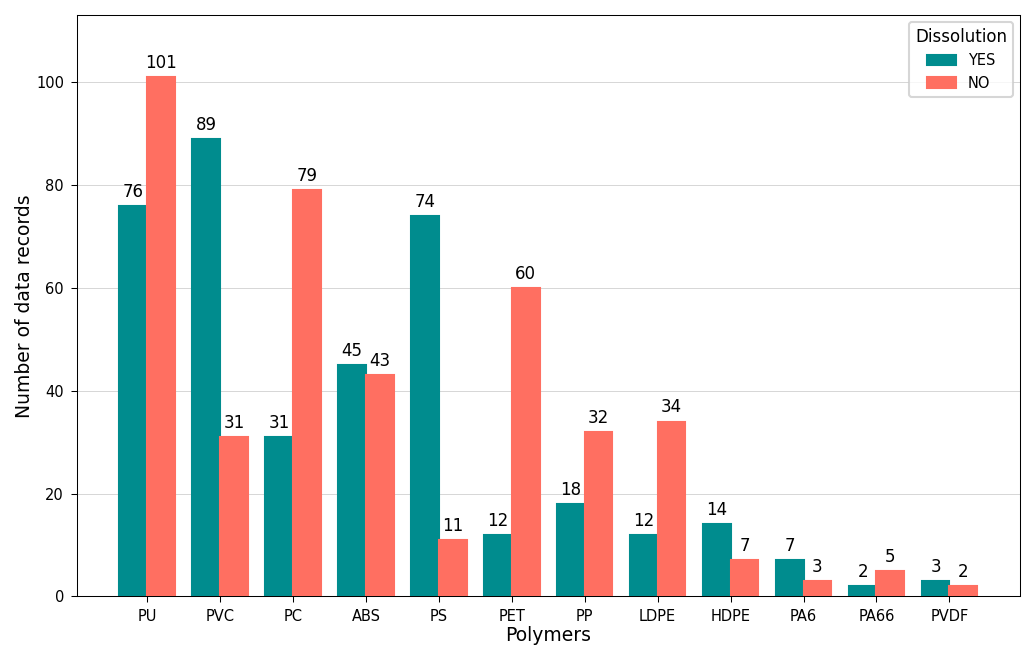

In [ ]:

polymer_counts_sorted = pd.crosstab(
    df_records["Polymer"],
    df_records["Dissolution"]
)
for col in ["YES", "NO"]:
    if col not in polymer_counts_sorted.columns:
        polymer_counts_sorted[col] = 0

polymer_counts_sorted = polymer_counts_sorted[["YES", "NO"]]

polymer_counts_sorted["Total"] = polymer_counts_sorted.sum(axis=1)
polymer_counts_sorted = polymer_counts_sorted.sort_values("Total", ascending=False)
polymer_counts_sorted = polymer_counts_sorted.drop(columns="Total")

fig, ax = plt.subplots(figsize=(7, 4.5))

x = np.arange(len(polymer_counts_sorted.index))
width = 0.38

bars_yes = ax.bar(
    x - width / 2,
    polymer_counts_sorted["YES"],
    width,
    label="YES",
    color="#008c8e",
    edgecolor="#008c8e",
    zorder=3
)

bars_no = ax.bar(
    x + width / 2,
    polymer_counts_sorted["NO"],
    width,
    label="NO",
    color="#ff6f61",
    edgecolor="#ff6f61",
    zorder=3
)

ax.set_xlabel("Polymers", fontsize=9)
ax.set_ylabel("Number of data records", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(polymer_counts_sorted.index)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_visible(True)

ax.tick_params(width=0.5, labelsize=7, direction="out")

ax.grid(axis='y', color='gray', linestyle='-', linewidth=0.3, alpha=0.5, zorder=0)

ymax = polymer_counts_sorted.values.max()
offset = 0.01 * ymax

for bars in [bars_yes, bars_no]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + offset,
                str(int(h)),
                ha='center',
                va='bottom',
                fontsize=8,
                color="black"
            )


ax.set_ylim(0, ymax * 1.12)

ax.legend(
    title="Dissolution",
    fontsize=7,
    title_fontsize=8,
    frameon=True
)

plt.tight_layout()
plt.show()

`Distribution: Plot target class distribution`

Dissolution
NO     408
YES    383
Name: count, dtype: int64


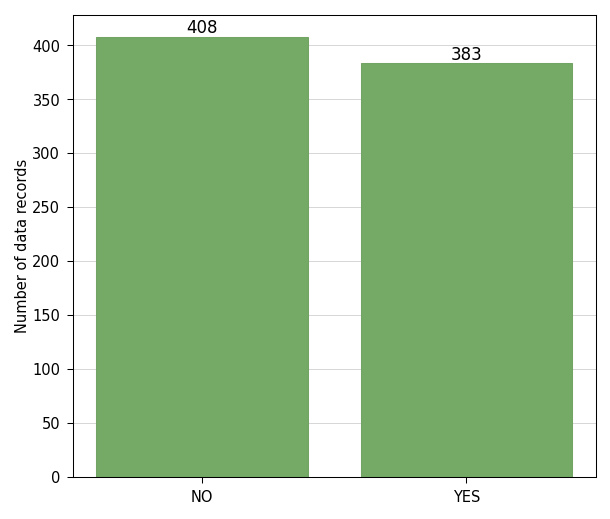

In [6]:
target = "Dissolution"

values = df_records[target].value_counts()
print(values)

figure(figsize=(4.5, 4))

plot_bar_chart(values.index.to_list(), values.to_list(), title="")

ax = gca()
ax.set_ylabel("Number of data records", fontsize=7)

for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_visible(True)

ax.tick_params(width=0.5, labelsize=7, direction="out")
ax.grid(axis="y", color="gray", linestyle="-", linewidth=0.3, alpha=0.5, zorder=0)

show()